Firstly, I try to do an algorithm solving for a 2d space with only one solution (1 peak).

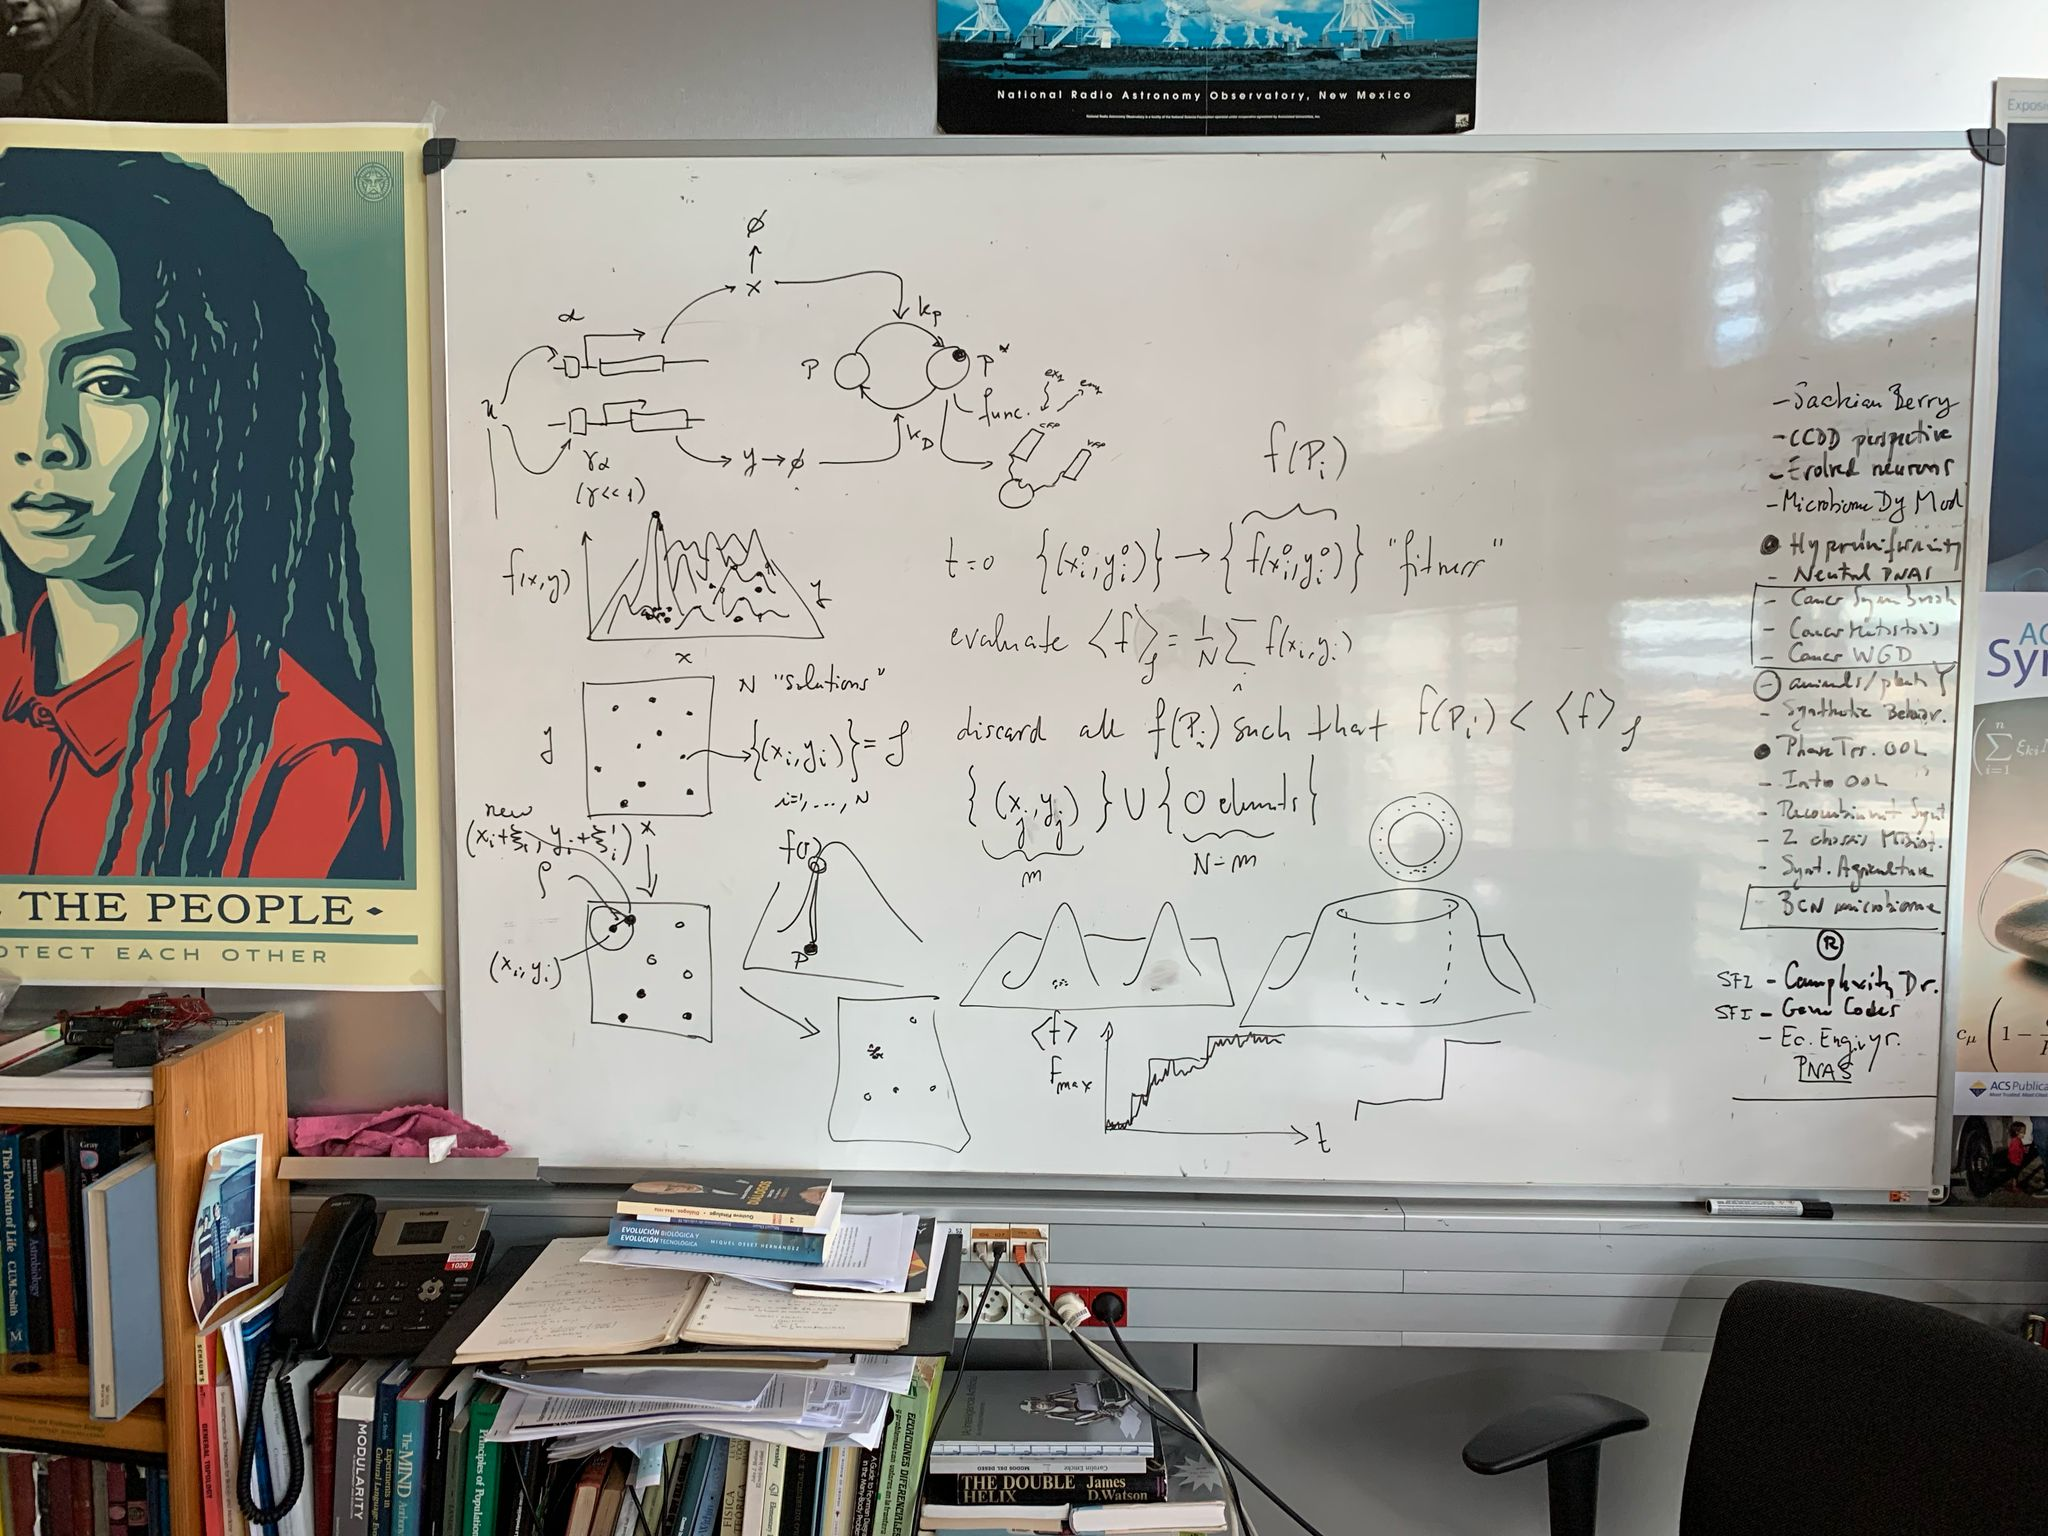

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm   # colormap
from matplotlib.ticker import LinearLocator     # for having ticks evenly spaced on the axis
from mpl_toolkits.mplot3d import Axes3D

import evolutionary_programming as ep

In [2]:
# fixed 1 gaussian peak 3d landscape
def f(x,y):
    return np.exp(-0.1*(x)**2 - 0.1*(y)**2)

In [3]:
par = {'N': 1000,
       'coord_range': np.array([0,10]),
       'sol_ratio': 1/5,    # eta
       'mutation_radius': 1/20, # mu
       'seed': 12345,
       'n_iter': 200,
       'eps': 0.01}  # epsilon (precision on convergence)

func_par = {'alphas': np.random.uniform(0.,2.,50),
            'offsetsx': np.random.uniform(0.,10.,50),
            'offsetsy':np.random.uniform(0.,10.,50)}

# generate a random 3d landscape by sum of gaussians whose parameters are extracted from a uniform distribution
def f(x,y,func_par:dict):
       alphas, offsetsx, offsetsy = func_par['alphas'], func_par['offsetsx'], func_par['offsetsy']
       f = np.zeros((x.shape))
       for i in range(len(alphas)):
              f += alphas[i] * np.exp(-(x-offsetsx[i])**2-(y-offsetsy[i])**2)     
       return f / np.max(f)

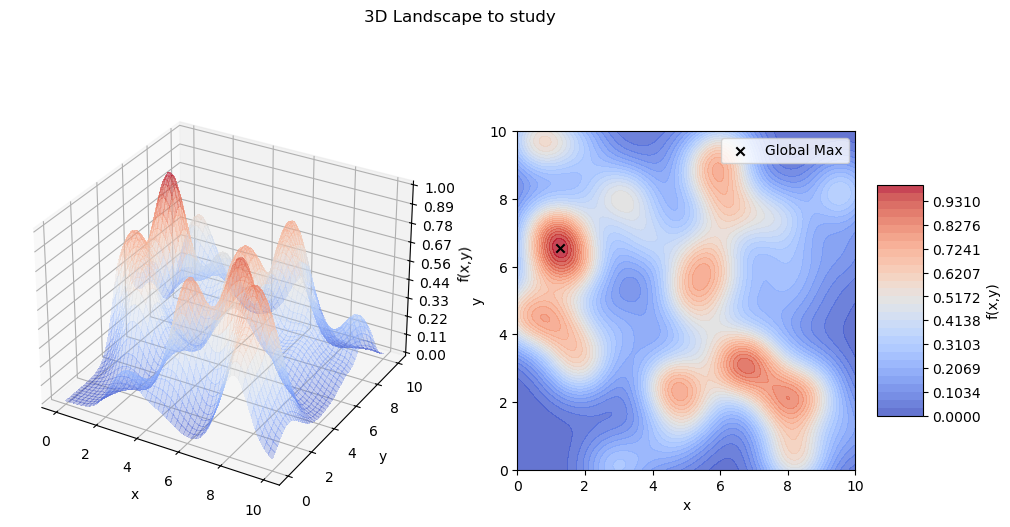

In [4]:
title = '3D Landscape to study'
coord_range = par['coord_range']
N = par['N']
x = np.linspace(coord_range[0],coord_range[1],N)
y = np.linspace(coord_range[0],coord_range[1],N)
X,Y = np.meshgrid(x,y)

fig= plt.figure(figsize=(12,6))
fig.suptitle(title)

# First subplot (3d view)
ax = fig.add_subplot(1,2,1,projection='3d')
surf = ax.plot_surface(X, Y, f(X,Y,func_par), cmap=cm.coolwarm, linewidth=0, antialiased=False,alpha=0.3)

# Customize the z axis.
ax.zaxis.set_major_locator(LinearLocator(10))
ax.set_zlim(0.0)
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

# Add axis labels
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')


# Second subplot (2d view)
ax = fig.add_subplot(1,2,2)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('x')
ax.set_ylabel('y')
levels = np.linspace(0,np.max(f(x,y,func_par)),30)
contour = ax.contourf(X,Y,f(X,Y,func_par),cmap=cm.coolwarm, antialiased=False,levels=levels,alpha=0.8)
ax.scatter(X[np.argmax(f(X,Y,func_par)) // N, np.argmax(f(X,Y,func_par)) % N], 
           Y[np.argmax(f(X,Y,func_par)) // N, np.argmax(f(X,Y,func_par)) % N], 
           marker='x', c='black', label='Global Max')
ax.legend()
# Add a color bar which maps values to colors.
fig.colorbar(contour, shrink=0.5, aspect=5,label='f(x,y)')

plt.savefig('plots/landscape.png')
plt.show()

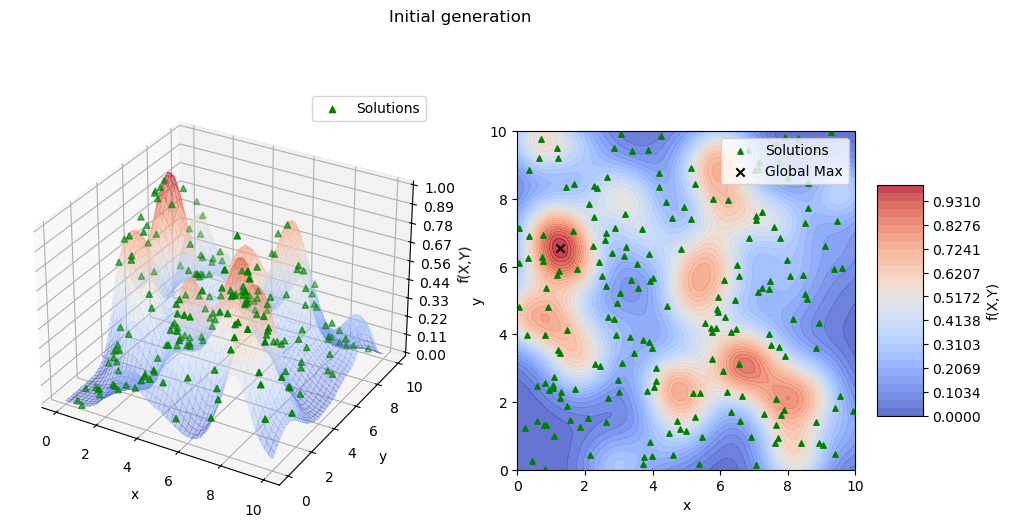

Iteration #0...


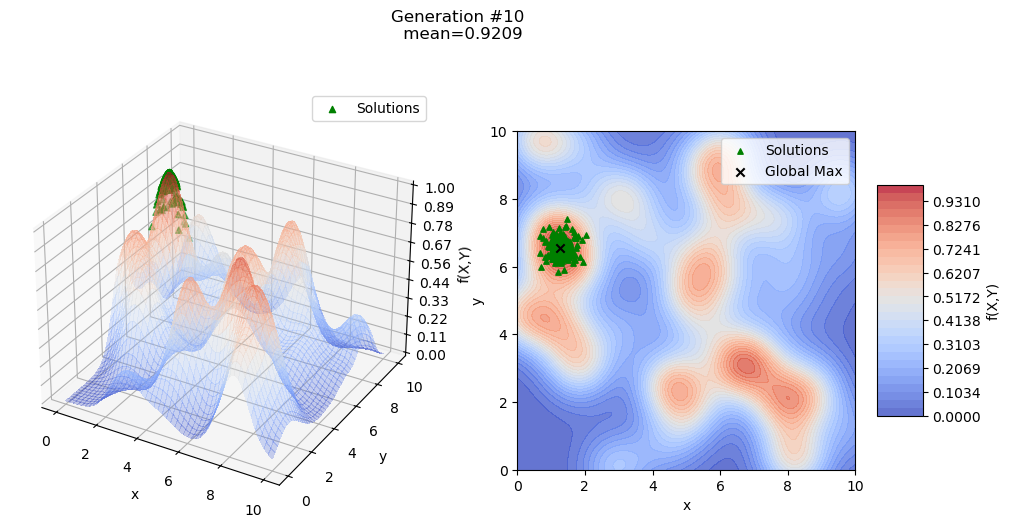

Iteration #10...
Iteration #20...
Iteration #30...
Iteration #40...
Iteration #50...
Iteration #60...
Iteration #70...
Iteration #80...
Iteration #90...
Iteration #100...
Convergence reached after 109 iterations.
Convergence reached after 109 iterations.


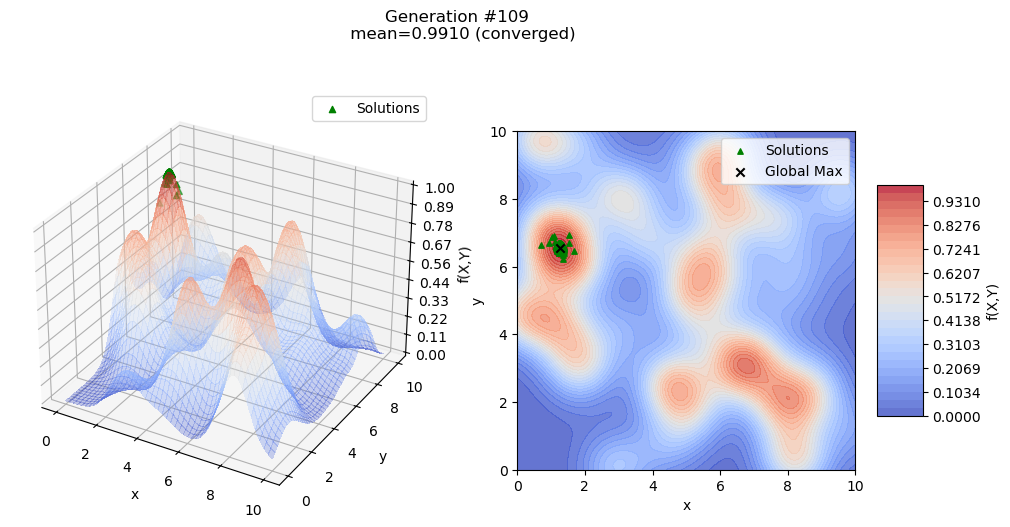

In [5]:
mean_ev, max_ev = ep.ep2d(f,par,func_par=func_par,verb=0)

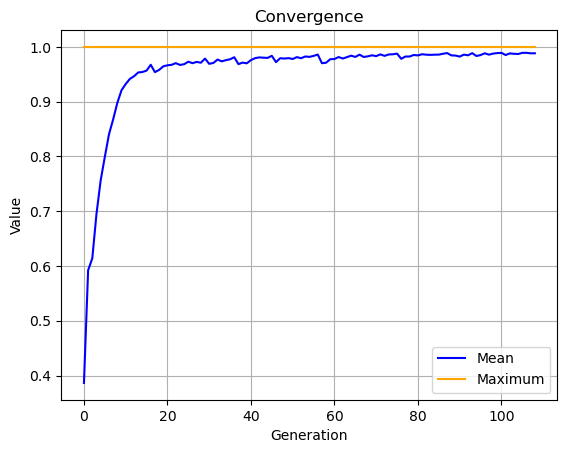

In [6]:
plt.plot(mean_ev,c='b',label='Mean')
plt.plot(max_ev,c='orange',label='Maximum')
plt.legend()
plt.grid(True)
plt.title('Convergence')
plt.ylabel('Value')
plt.xlabel('Generation')
plt.savefig('plots/convergence.png')
plt.show()

In [7]:
np.max(f(X,Y,func_par))
mean_ev

array([0.38648875, 0.59214402, 0.61406648, 0.69492775, 0.75608007,
       0.79926937, 0.8405613 , 0.86784567, 0.89802827, 0.92089989,
       0.93224506, 0.94161983, 0.94647686, 0.95340239, 0.95418575,
       0.95677943, 0.96739018, 0.95399802, 0.95796616, 0.96450537,
       0.96646036, 0.9673199 , 0.97037746, 0.96710892, 0.96847982,
       0.9730189 , 0.97030337, 0.97264665, 0.9711582 , 0.97869972,
       0.96916281, 0.97071642, 0.97696031, 0.97365342, 0.97580865,
       0.977462  , 0.98115588, 0.96858994, 0.97131836, 0.97006912,
       0.9759261 , 0.97954774, 0.98087362, 0.98033165, 0.97998063,
       0.98374394, 0.97222305, 0.97937728, 0.97877189, 0.97951937,
       0.97797315, 0.98140107, 0.97938525, 0.98250272, 0.98187397,
       0.98356276, 0.98612812, 0.97029235, 0.97116366, 0.97756204,
       0.9779291 , 0.98153977, 0.97880438, 0.98139612, 0.98405631,
       0.98170962, 0.98584224, 0.98170079, 0.98279376, 0.98466351,
       0.98320422, 0.98636025, 0.98368213, 0.98620381, 0.98655